In [1]:
#we may need some code in the ../python directory and/or matplotlib styles
import sys
sys.path.append('../python/')

#matplotlib for plotting
import matplotlib as mpl
from matplotlib import pyplot as plt
plt.style.use('../mplstyles/stylelib/standard.mplstyle')

#other computational libraries
import numpy as np
import pandas as pds
import math
import time

In [2]:
#set up the parameters for the cylindrical detector
R = 1
h = 1
a = 1.3

In [3]:
from scipy import integrate
#def cos_int(x):
#  f = lambda u: (a+1)*np.power(u,a)
#  return integrate.quad(f,0,x)[0]

def cos_int(x):
    f = lambda u: (a + 1) * np.power(u, a)

    if np.isscalar(x):
        return integrate.quad(f, 0, x)[0]
    else:
        return np.array([integrate.quad(f, 0, xi)[0] for xi in x])

print(cos_int(0.9999999))

from scipy import optimize
#def inv_cos_int(y):
#  g = lambda v: cos_int(v)-y
#  return optimize.root(g,0.5).x[0]

def inv_cos_int(y):
    
    def solve_one(yi):
        g = lambda v: cos_int(v) - yi
        return optimize.root(g, 0.5).x[0]

    if np.isscalar(y):
        return solve_one(y)
    else:
        y = np.asarray(y)
        return np.array([solve_one(yi) for yi in y])

print(inv_cos_int([0.5,0.6]))
print(cos_int(0.8409))

0.999999770000015
[0.73980522 0.8008368 ]
0.6712928333118727


In [9]:
#the monte carlo way
start = time.time()
L = 5
N = int(1e8)
X = np.random.uniform(-L,L,N)
Y = np.random.uniform(-L,L,N)
R0 = np.sqrt(X**2,Y**2)

end = time.time()

print('Evaluation Time (Radial): {:1.5f} sec. for {:7d} points'.format(end-start,N))

#generate angles

phi = np.random.uniform(-np.pi,np.pi,N)
start = time.time()

#try accept/reject memthod from GPT version instead
costhet = np.random.rand(N)
accept = np.random.rand(N) < np.power(costhet,a)
#inv_costhet = np.random.uniform(0,1,N)
#costhet = inv_cos_int(inv_costhet)
end = time.time()

#recast all vectors
X = X[accept]
Y = Y[accept]
R0 = R0[accept]
costhet = costhet[accept]
phi = phi[accept]

print('Evaluation Time (Angular): {:1.5f} sec. for {:7d} points'.format(end-start,np.sum(accept)))


#slice things up

cInside = (R0<=R)
cInWall = cInside&(costhet<(R/np.sqrt(R**2+h**2)))
cInTop = cInside&(costhet>=(R/np.sqrt(R**2+h**2)))
#print(np.shape(R0[cInWall]),np.shape(R0[cInTop]))

lall = []


r=R0
#print(R/r)
#print(np.max(R/r),np.min(R/r))
r = r[~cInside]
phi = phi[~cInside]
costhet = costhet[~cInside]

cPhi = (-np.arcsin(R/r)<phi)&(phi<np.arcsin(R/r))

r = r[cPhi]
phi = phi[cPhi]
costhet = costhet[cPhi]

t = 2*np.sqrt(R**2 - r**2*np.sin(phi)**2)
d = r*np.cos(phi) - np.sqrt(R**2 - r**2*np.sin(phi)**2)

maxcos = h/np.sqrt((d+t)**2+h**2)
cCos = (costhet>0)&(costhet<=maxcos)

r = r[cCos]
phi = phi[cCos]
costhet = costhet[cCos]
t = t[cCos]
d = d[cCos]

lcomp = t/np.sqrt(1-costhet**2)

lall = lcomp

#print(R0)
print(np.shape(R0),np.shape(lcomp))



Evaluation Time (Radial): 1.09700 sec. for 100000000 points
Evaluation Time (Angular): 3.17317 sec. for 43472263 points
(43472263,) (529161,)


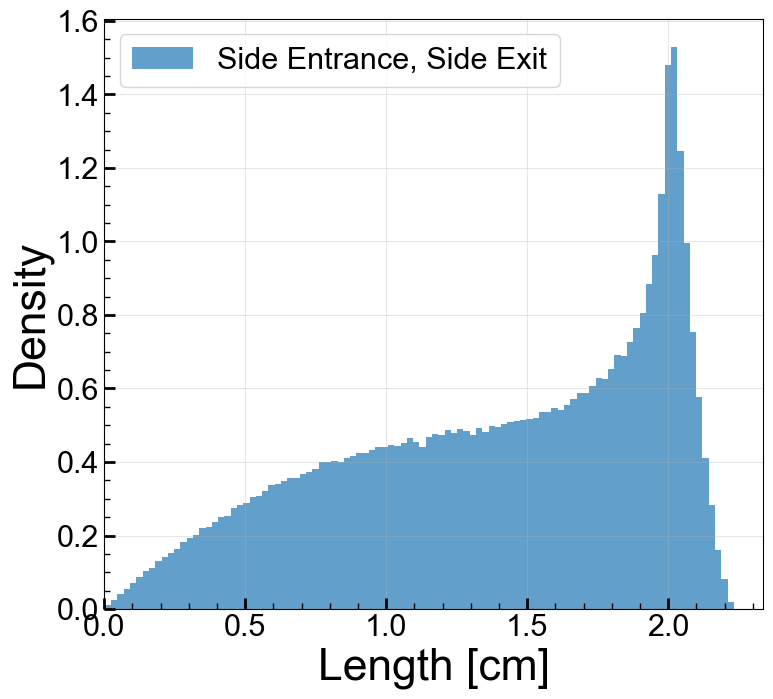

In [6]:
# Create figure with two subplots
fig, (ax1) = plt.subplots(1, 1, figsize=(8, 7))


xmax = np.sqrt((2*R)**2+h**2)+0.1
xplot = np.linspace(0,xmax, 10000)

ax1.hist(lall, bins=100, density=True, alpha=0.7, label='Side Entrance, Side Exit',align='mid')


ax1.set_xlim(0.0, xmax) 
ax1.set_ylabel('Density')
ax1.set_xlabel('Length [cm]')
#ax1.set_title('Histogram of Chi-Square per DOF')
ax1.legend()
ax1.grid(True, alpha=0.3)


# Adjust layout and save
plt.tight_layout()
plt.show()